### Cell 1 Setup

In [1]:
from pathlib import Path
import json
import random
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


def find_project_root() -> Path:
    current_path = Path.cwd().resolve()

    if current_path.name == "notebooks":
        return current_path.parent

    if (current_path / "data").exists():
        return current_path

    for parent in current_path.parents:
        if (parent / "data").exists():
            return parent

    return current_path


PROJECT_ROOT = find_project_root()

CONFIG = {
    "project_root": PROJECT_ROOT,
    "input_csv_path": PROJECT_ROOT / "data" / "processed" / "dry_bean_initial_clean_copy.csv",
    "raw_excel_path": PROJECT_ROOT / "data" / "raw" / "Dry_Bean_Dataset.xlsx",
    "processed_dir": PROJECT_ROOT / "data" / "processed",
    "preprocessing_model_dir": PROJECT_ROOT / "models" / "preprocessing",
    "results_dir": PROJECT_ROOT / "results" / "02_preprocessing",
    "plots_dir": PROJECT_ROOT / "plots" / "02_preprocessing",
    "target_column": "Class",
    "test_size": 0.20,
    "random_seed": RANDOM_SEED,
}

for directory in [
    CONFIG["processed_dir"],
    CONFIG["preprocessing_model_dir"],
    CONFIG["results_dir"],
    CONFIG["plots_dir"],
]:
    directory.mkdir(parents=True, exist_ok=True)

print("Setup completed.")
print(f"Project root: {PROJECT_ROOT}")

Setup completed.
Project root: /home/iailab42/khans1/projects/xai


### Cell 2 — Helper Functions
functions to load data, remove duplicates, encode labels, calculate class distribution, and save JSON files.

In [2]:
def load_dry_bean_data(config: dict) -> pd.DataFrame:
    if config["input_csv_path"].exists():
        df = pd.read_csv(config["input_csv_path"])
        print(f"Loaded CSV file: {config['input_csv_path']}")
        return df

    if config["raw_excel_path"].exists():
        df = pd.read_excel(config["raw_excel_path"])
        print(f"Loaded Excel file: {config['raw_excel_path']}")
        return df

    raise FileNotFoundError(
        "Dataset not found. Expected either:\n"
        f"1. {config['input_csv_path']}\n"
        f"2. {config['raw_excel_path']}"
    )


def remove_exact_duplicates(df: pd.DataFrame) -> tuple[pd.DataFrame, dict]:
    original_rows = len(df)
    duplicate_rows = int(df.duplicated().sum())

    df_clean = df.drop_duplicates().reset_index(drop=True)
    df_clean.insert(0, "sample_id", range(len(df_clean)))

    duplicate_summary = {
        "original_rows": original_rows,
        "duplicate_rows_removed": duplicate_rows,
        "remaining_rows": len(df_clean),
        "duplicate_percentage": round((duplicate_rows / original_rows) * 100, 4),
    }

    return df_clean, duplicate_summary


def encode_target(y: pd.Series) -> tuple[np.ndarray, LabelEncoder, dict]:
    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y)

    label_mapping = {
        class_name: int(encoded_value)
        for encoded_value, class_name in enumerate(label_encoder.classes_)
    }

    return y_encoded, label_encoder, label_mapping


def get_class_distribution(labels: pd.Series, split_name: str) -> pd.DataFrame:
    counts = labels.value_counts().sort_index()
    percentages = (counts / len(labels)) * 100

    return pd.DataFrame({
        "split": split_name,
        "class_name": counts.index,
        "count": counts.values,
        "percentage": percentages.values,
    })


def save_json(data: dict, save_path: Path) -> None:
    with open(save_path, "w") as file:
        json.dump(data, file, indent=4)


def show_dataframe(df: pd.DataFrame, title: str = "") -> None:
    if title:
        print(title)

    try:
        display(df)
    except NameError:
        print(df)

### Cell 3 — Load Data and Remove Duplicates

In [3]:
df = load_dry_bean_data(CONFIG)

target_column = CONFIG["target_column"]

if target_column not in df.columns:
    raise ValueError(f"Target column '{target_column}' not found in dataset.")

df_no_duplicates, duplicate_summary = remove_exact_duplicates(df)

print("Duplicate removal completed.")
print(duplicate_summary)

no_duplicate_path = CONFIG["processed_dir"] / "dry_bean_no_duplicates.csv"
df_no_duplicates.to_csv(no_duplicate_path, index=False)

print(f"Dataset without duplicates saved to: {no_duplicate_path}")

Loaded CSV file: /home/iailab42/khans1/projects/xai/data/processed/dry_bean_initial_clean_copy.csv
Duplicate removal completed.
{'original_rows': 13611, 'duplicate_rows_removed': 68, 'remaining_rows': 13543, 'duplicate_percentage': 0.4996}
Dataset without duplicates saved to: /home/iailab42/khans1/projects/xai/data/processed/dry_bean_no_duplicates.csv


### Cell 4 — Split Features and Encode Target

In [4]:
feature_columns = [
    column for column in df_no_duplicates.columns
    if column not in ["sample_id", target_column]
]

X = df_no_duplicates[feature_columns]
y_original = df_no_duplicates[target_column]
sample_ids = df_no_duplicates["sample_id"]

y_encoded, label_encoder, label_mapping = encode_target(y_original)

print("Feature and target separation completed.")
print(f"Number of features: {len(feature_columns)}")
print(f"Number of classes: {len(label_mapping)}")
print("Label mapping:")
print(label_mapping)

Feature and target separation completed.
Number of features: 16
Number of classes: 7
Label mapping:
{'BARBUNYA': 0, 'BOMBAY': 1, 'CALI': 2, 'DERMASON': 3, 'HOROZ': 4, 'SEKER': 5, 'SIRA': 6}


### Cell 5 — Stratified Train-Test Split
stratified splitting because the class distribution is imbalanced.

In [5]:
(
    X_train,
    X_test,
    y_train_encoded,
    y_test_encoded,
    y_train_original,
    y_test_original,
    train_sample_ids,
    test_sample_ids,
) = train_test_split(
    X,
    y_encoded,
    y_original,
    sample_ids,
    test_size=CONFIG["test_size"],
    random_state=CONFIG["random_seed"],
    stratify=y_encoded,
)

X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)

y_train_original = pd.Series(y_train_original).reset_index(drop=True)
y_test_original = pd.Series(y_test_original).reset_index(drop=True)

train_sample_ids = pd.Series(train_sample_ids).reset_index(drop=True)
test_sample_ids = pd.Series(test_sample_ids).reset_index(drop=True)

print("Train-test split completed.")
print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

Train-test split completed.
Training samples: 10834
Test samples: 2709


### Cell 6 — Scale Features
StandardScaler. Fit only on training data, then transform both training and test data.

In [6]:
scaler = StandardScaler()

X_train_scaled_array = scaler.fit_transform(X_train)
X_test_scaled_array = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled_array, columns=feature_columns)
X_test_scaled = pd.DataFrame(X_test_scaled_array, columns=feature_columns)

scaling_summary = pd.DataFrame({
    "feature": feature_columns,
    "train_mean_before_scaling": X_train.mean().values,
    "train_std_before_scaling": X_train.std().values,
    "train_mean_after_scaling": X_train_scaled.mean().values,
    "train_std_after_scaling": X_train_scaled.std().values,
})

show_dataframe(scaling_summary.head(), "Scaling summary preview")

print("Feature scaling completed.")
print(f"Maximum absolute scaled train mean: {abs(X_train_scaled.mean()).max():.8f}")

Scaling summary preview


,feature,train_mean_before_scaling,train_std_before_scaling,train_mean_after_scaling,train_std_after_scaling
0,Area,53017.520214,29355.864916,-6.558452e-17,1.000046
1,Perimeter,854.636015,214.483912,2.820135e-16,1.000046
2,MajorAxisLength,319.786381,85.721678,-1.580587e-16,1.000046
3,MinorAxisLength,202.323863,45.048331,-5.128710e-16,1.000046
4,AspectRation,1.580852,0.245198,4.590917e-17,1.000046


Feature scaling completed.
Maximum absolute scaled train mean: 0.00000000


### Cell 7 — Save Processed Data and Objects

In [7]:
y_train_df = pd.DataFrame({
    "sample_id": train_sample_ids,
    "Class_encoded": y_train_encoded,
    "Class": y_train_original,
})

y_test_df = pd.DataFrame({
    "sample_id": test_sample_ids,
    "Class_encoded": y_test_encoded,
    "Class": y_test_original,
})

train_sample_ids_df = pd.DataFrame({"sample_id": train_sample_ids})
test_sample_ids_df = pd.DataFrame({"sample_id": test_sample_ids})

df_processed = df_no_duplicates.copy()
df_processed["Class_encoded"] = label_encoder.transform(df_processed[target_column])

save_paths = {
    "processed_full_dataset": CONFIG["processed_dir"] / "dry_bean_processed.csv",
    "X_train": CONFIG["processed_dir"] / "X_train.csv",
    "X_test": CONFIG["processed_dir"] / "X_test.csv",
    "X_train_scaled": CONFIG["processed_dir"] / "X_train_scaled.csv",
    "X_test_scaled": CONFIG["processed_dir"] / "X_test_scaled.csv",
    "y_train": CONFIG["processed_dir"] / "y_train.csv",
    "y_test": CONFIG["processed_dir"] / "y_test.csv",
    "train_sample_ids": CONFIG["processed_dir"] / "train_sample_ids.csv",
    "test_sample_ids": CONFIG["processed_dir"] / "test_sample_ids.csv",
    "scaling_summary": CONFIG["results_dir"] / "feature_scaling_summary.csv",
}

df_processed.to_csv(save_paths["processed_full_dataset"], index=False)
X_train.to_csv(save_paths["X_train"], index=False)
X_test.to_csv(save_paths["X_test"], index=False)
X_train_scaled.to_csv(save_paths["X_train_scaled"], index=False)
X_test_scaled.to_csv(save_paths["X_test_scaled"], index=False)
y_train_df.to_csv(save_paths["y_train"], index=False)
y_test_df.to_csv(save_paths["y_test"], index=False)
train_sample_ids_df.to_csv(save_paths["train_sample_ids"], index=False)
test_sample_ids_df.to_csv(save_paths["test_sample_ids"], index=False)
scaling_summary.to_csv(save_paths["scaling_summary"], index=False)

label_encoder_path = CONFIG["preprocessing_model_dir"] / "label_encoder.pkl"
scaler_path = CONFIG["preprocessing_model_dir"] / "standard_scaler.pkl"

joblib.dump(label_encoder, label_encoder_path)
joblib.dump(scaler, scaler_path)

feature_columns_path = CONFIG["results_dir"] / "feature_columns.json"
label_mapping_path = CONFIG["results_dir"] / "label_mapping.json"

save_json({"feature_columns": feature_columns}, feature_columns_path)
save_json(label_mapping, label_mapping_path)

print("Processed data and preprocessing objects saved.")

Processed data and preprocessing objects saved.


### Cell 8 — Save Class Distribution After Split

In [8]:
full_distribution = get_class_distribution(y_original, "full_cleaned_data")
train_distribution = get_class_distribution(y_train_original, "train")
test_distribution = get_class_distribution(y_test_original, "test")

class_distribution_after_split = pd.concat(
    [full_distribution, train_distribution, test_distribution],
    ignore_index=True,
)

class_distribution_path = CONFIG["results_dir"] / "class_distribution_after_split.csv"
class_distribution_after_split.to_csv(class_distribution_path, index=False)

show_dataframe(class_distribution_after_split, "Class distribution after split")

print(f"Class distribution after split saved to: {class_distribution_path}")

Class distribution after split


,split,class_name,count,percentage
0,full_cleaned_data,BARBUNYA,1322,9.761500
1,full_cleaned_data,BOMBAY,522,3.854390
2,full_cleaned_data,CALI,1630,12.035738
3,full_cleaned_data,DERMASON,3546,26.183268
4,full_cleaned_data,HOROZ,1860,13.734032
5,full_cleaned_data,SEKER,2027,14.967142
6,full_cleaned_data,SIRA,2636,19.463930
7,train,BARBUNYA,1057,9.756323
8,train,BOMBAY,418,3.858224
9,train,CALI,1304,12.036182


Class distribution after split saved to: /home/iailab42/khans1/projects/xai/results/02_preprocessing/class_distribution_after_split.csv


### Cell 9 — Preprocessing Plots

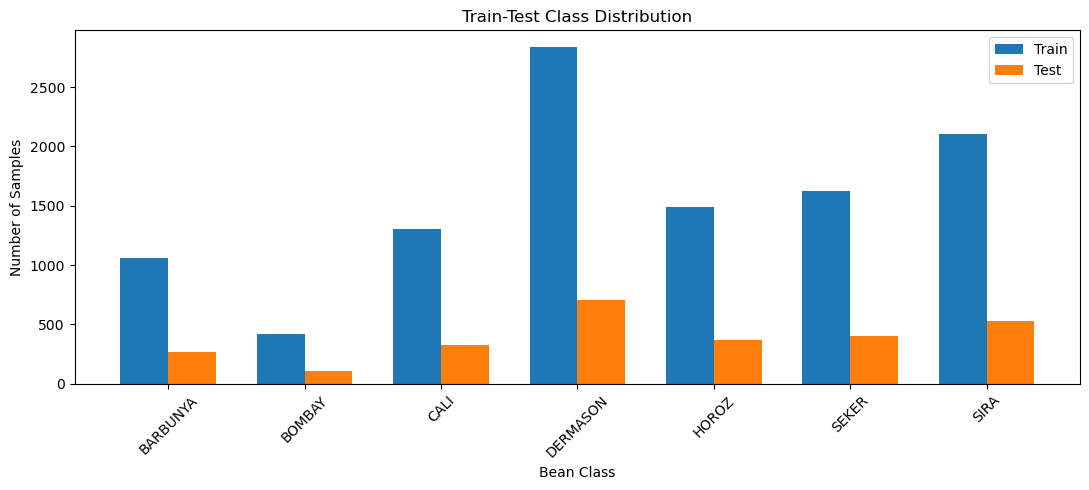

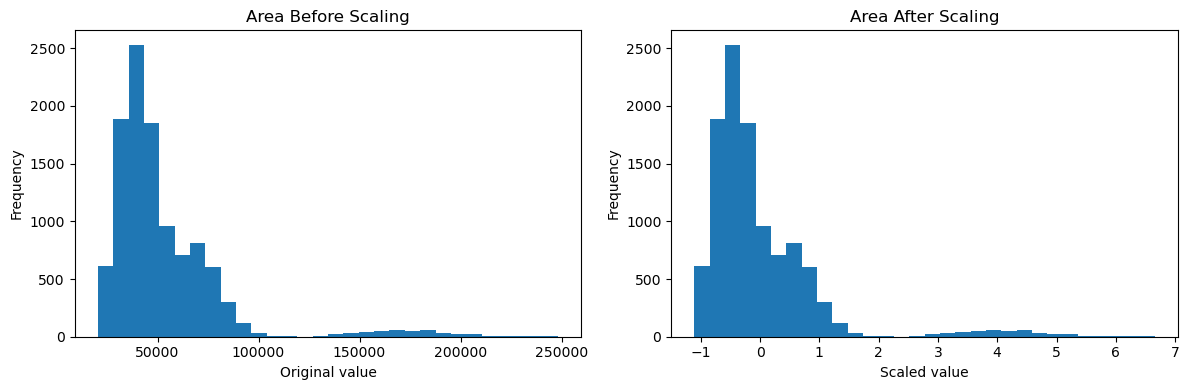

Class distribution plot saved to: /home/iailab42/khans1/projects/xai/plots/02_preprocessing/train_test_class_distribution.png
Scaling example plot saved to: /home/iailab42/khans1/projects/xai/plots/02_preprocessing/scaling_example_area.png


In [9]:
def plot_train_test_class_distribution(
    class_distribution_df: pd.DataFrame,
    save_path: Path
) -> None:
    plot_df = class_distribution_df[
        class_distribution_df["split"].isin(["train", "test"])
    ]

    pivot_df = plot_df.pivot(
        index="class_name",
        columns="split",
        values="count"
    )

    classes = pivot_df.index.tolist()
    x_positions = np.arange(len(classes))
    bar_width = 0.35

    plt.figure(figsize=(11, 5))
    plt.bar(x_positions - bar_width / 2, pivot_df["train"], width=bar_width, label="Train")
    plt.bar(x_positions + bar_width / 2, pivot_df["test"], width=bar_width, label="Test")

    plt.title("Train-Test Class Distribution")
    plt.xlabel("Bean Class")
    plt.ylabel("Number of Samples")
    plt.xticks(x_positions, classes, rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


def plot_scaling_example(
    X_train: pd.DataFrame,
    X_train_scaled: pd.DataFrame,
    feature_name: str,
    save_path: Path
) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(X_train[feature_name], bins=30)
    axes[0].set_title(f"{feature_name} Before Scaling")
    axes[0].set_xlabel("Original value")
    axes[0].set_ylabel("Frequency")

    axes[1].hist(X_train_scaled[feature_name], bins=30)
    axes[1].set_title(f"{feature_name} After Scaling")
    axes[1].set_xlabel("Scaled value")
    axes[1].set_ylabel("Frequency")

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


class_plot_path = CONFIG["plots_dir"] / "train_test_class_distribution.png"
scaling_plot_path = CONFIG["plots_dir"] / "scaling_example_area.png"

plot_train_test_class_distribution(
    class_distribution_df=class_distribution_after_split,
    save_path=class_plot_path,
)

plot_scaling_example(
    X_train=X_train,
    X_train_scaled=X_train_scaled,
    feature_name="Area",
    save_path=scaling_plot_path,
)

print(f"Class distribution plot saved to: {class_plot_path}")
print(f"Scaling example plot saved to: {scaling_plot_path}")

### Cell 10 — Final Preprocessing Summary

In [10]:
preprocessing_summary = {
    "original_rows": int(duplicate_summary["original_rows"]),
    "duplicate_rows_removed": int(duplicate_summary["duplicate_rows_removed"]),
    "rows_after_duplicate_removal": int(duplicate_summary["remaining_rows"]),
    "number_of_features": int(len(feature_columns)),
    "target_column": target_column,
    "number_of_classes": int(len(label_mapping)),
    "label_mapping": label_mapping,
    "test_size": CONFIG["test_size"],
    "train_samples": int(len(X_train)),
    "test_samples": int(len(X_test)),
    "random_seed": CONFIG["random_seed"],
    "split_type": "stratified",
    "scaler": "StandardScaler",
    "scaler_fit_on": "training data only",
    "saved_scaled_features": True,
    "saved_unscaled_features": True,
}

preprocessing_summary_path = CONFIG["results_dir"] / "preprocessing_summary.json"
save_json(preprocessing_summary, preprocessing_summary_path)

print("Preprocessing summary")
print(json.dumps(preprocessing_summary, indent=4))

print(f"Preprocessing summary saved to: {preprocessing_summary_path}")

Preprocessing summary
{
    "original_rows": 13611,
    "duplicate_rows_removed": 68,
    "rows_after_duplicate_removal": 13543,
    "number_of_features": 16,
    "target_column": "Class",
    "number_of_classes": 7,
    "label_mapping": {
        "BARBUNYA": 0,
        "BOMBAY": 1,
        "CALI": 2,
        "DERMASON": 3,
        "HOROZ": 4,
        "SEKER": 5,
        "SIRA": 6
    },
    "test_size": 0.2,
    "train_samples": 10834,
    "test_samples": 2709,
    "random_seed": 42,
    "split_type": "stratified",
    "scaler": "StandardScaler",
    "scaler_fit_on": "training data only",
    "saved_scaled_features": true,
    "saved_unscaled_features": true
}
Preprocessing summary saved to: /home/iailab42/khans1/projects/xai/results/02_preprocessing/preprocessing_summary.json


In [11]:
assert len(X_train) == len(y_train_df), "X_train and y_train length mismatch."
assert len(X_test) == len(y_test_df), "X_test and y_test length mismatch."
assert X_train.shape[1] == len(feature_columns), "Feature count mismatch in X_train."
assert X_test.shape[1] == len(feature_columns), "Feature count mismatch in X_test."
assert X_train_scaled.shape == X_train.shape, "Scaled train shape mismatch."
assert X_test_scaled.shape == X_test.shape, "Scaled test shape mismatch."
assert set(y_train_original.unique()) == set(y_original.unique()), "Some classes missing in train set."
assert set(y_test_original.unique()) == set(y_original.unique()), "Some classes missing in test set."

print("All preprocessing checks passed.")
print("Notebook 02 completed successfully.")

All preprocessing checks passed.
Notebook 02 completed successfully.
